In [47]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [48]:
# Path and categories
# Add 'r' before the quotes to treat backslashes as literal text
data_path = r'D:\BE. CSE\Sem 6\IoT_lab\sr\baby_cry_detector\dataset'
categories = ['baby_cry', 'baby_laugh', 'noise', 'silence']


In [49]:
# Parameters
sr = 22050  # Sample rate
duration = 5  # seconds
max_len = sr * duration

In [50]:

def extract_features(file_path, n_mfcc=40):
    try:
        y, sr = librosa.load(file_path, sr=22050, duration=duration)
        if len(y) < max_len:
            y = np.pad(y, (0, max_len - len(y)))
        else:
            y = y[:max_len]
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc = mfcc.astype(np.float32)
        return mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def load_dataset():
    X, y = [], []
    for label in categories:
        folder_path = os.path.join(data_path, label)
        for filename in os.listdir(folder_path):
            if filename.endswith('.wav'):
                file_path = os.path.join(folder_path, filename)
                features = extract_features(file_path)
                if features is not None:
                    X.append(features)
                    y.append(label)
    return np.array(X), np.array(y)


Loading dataset...
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 38, 214, 32)       320       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 19, 107, 32)      0         
 2D)                                                             
                                                                 
 batch_normalization_4 (Batc  (None, 19, 107, 32)      128       
 hNormalization)                                                 
                                                                 
 conv2d_5 (Conv2D)           (None, 17, 105, 64)       18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 8, 52, 64)        0         
 2D)                                                             
                                   

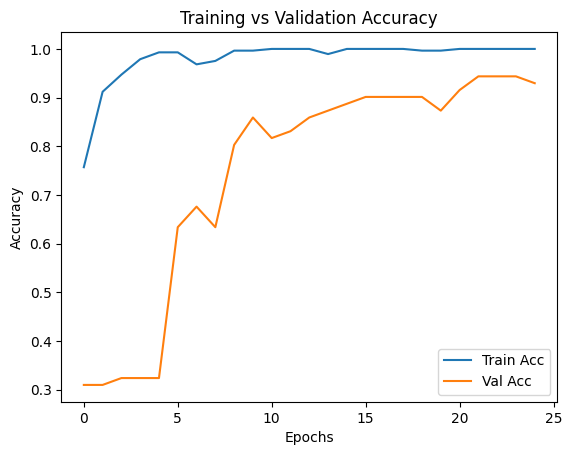

In [51]:

print("Loading dataset...")
X, y = load_dataset()
X = X[..., np.newaxis]  # (samples, 40, time_steps, 1)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = tf.keras.utils.to_categorical(y_encoded, num_classes=len(categories))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

# Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(40, X.shape[2], 1)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train
history = model.fit(X_train, y_train, epochs=25, batch_size=32,
                    validation_data=(X_test, y_test))

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.2f}")

# Save model
model.save("baby_sound_classifier.h5")
print("Model saved as baby_sound_classifier.h5")

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [52]:
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load your trained model
model = load_model("baby_sound_classifier.h5")

# Your label encoder categories
categories = ['baby_cry', 'baby_laugh', 'noise', 'silence']

def extract_features(file_path, sr=22050, duration=5, n_mfcc=40):
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=duration)
        max_len = sr * duration
        if len(y) < max_len:
            y = np.pad(y, (0, max_len - len(y)))
        else:
            y = y[:max_len]
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc = mfcc.astype(np.float32)
        mfcc = mfcc[..., np.newaxis]  # Add channel dimension
        return mfcc
    except Exception as e:
        print(f"Error extracting features: {e}")
        return None

def predict_sound(file_path):
    features = extract_features(file_path)
    if features is not None:
        features = np.expand_dims(features, axis=0)  # (1, 40, time_steps, 1)
        prediction = model.predict(features)
        predicted_index = np.argmax(prediction)
        predicted_label = categories[predicted_index]
        confidence = prediction[0][predicted_index]
        print(f"Predicted: {predicted_label} (Confidence: {confidence:.2f})")
    else:
        print("Could not extract features from the file.")

# Example usage
# test_file = "E:\\baby cry detector\\dataset\\baby_laugh\\laugh_2.m4a_2.wav" # Replace with your test .wav file path
# Example using an existing file from your dataset
test_file = r'D:\BE. CSE\Sem 6\IoT_lab\sr\baby_cry_detector\dataset\baby_laugh\laugh_1.wav'
predict_sound(test_file)

Error extracting features: [Errno 2] No such file or directory: 'D:\\BE. CSE\\Sem 6\\IoT_lab\\sr\\baby_cry_detector\\dataset\\baby_laugh\\laugh_1.wav'
Could not extract features from the file.


C:\Users\Admin\AppData\Local\Temp\ipykernel_23460\1274630096.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=sr, duration=duration)
C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


3/3 [==============================] - 0s 26ms/step
Confusion Matrix:
 [[22  0  0  0]
 [ 3 18  0  0]
 [ 1  0  4  1]
 [ 0  0  0 22]]

Classification Report:
              precision    recall  f1-score   support

    baby_cry       0.85      1.00      0.92        22
  baby_laugh       1.00      0.86      0.92        21
       noise       1.00      0.67      0.80         6
     silence       0.96      1.00      0.98        22

    accuracy                           0.93        71
   macro avg       0.95      0.88      0.90        71
weighted avg       0.94      0.93      0.93        71



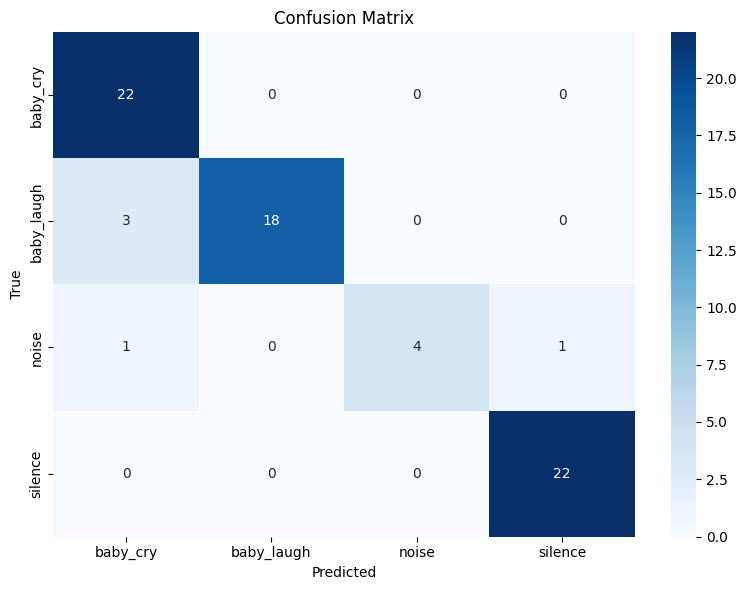

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Assuming you already have:
# - X_test: your test features
# - y_test: your one-hot encoded test labels
# - model: your trained model
# - categories: list of class names

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=categories))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [54]:
import tensorflow as tf

# Load your trained model
model = tf.keras.models.load_model("baby_sound_classifier.h5")

# Convert to TFLite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the .tflite file
with open("baby_sound_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print("Model converted and saved as baby_sound_classifier.tflite")


INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpvesyc8c6\assets


INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpvesyc8c6\assets


Model converted and saved as baby_sound_classifier.tflite


In [55]:
interpreter = tf.lite.Interpreter(model_path="baby_sound_classifier.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

categories = ['baby_cry', 'baby_laugh', 'noise', 'silence']

In [56]:

import numpy as np
import librosa
import tensorflow as tf
import tkinter as tk
from tkinter import filedialog, messagebox
import pygame  # Added for audio playback

# --- Initialize Pygame Mixer ---
pygame.mixer.init()

# --- Load the TFLite Interpreter ---
interpreter = tf.lite.Interpreter(model_path="baby_sound_classifier.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# CORRECTED ORDER: Alphabetical based on your notebook's LabelEncoder logic
categories = ['baby_cry', 'baby_laugh', 'noise', 'silence']

def predict_sound(file_path):
    try:
        # 1. Play the sound immediately [New Feature]
        pygame.mixer.music.load(file_path)
        pygame.mixer.music.play()

        # 2. Load and preprocess (Match training: 22050Hz, 5 seconds)
        y, sr = librosa.load(file_path, sr=22050, duration=5)
        target_length = 22050 * 5
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)))
        else:
            y = y[:target_length]
        
        # 3. Extract MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        
        # 4. Shape fixing (Ensure width matches 216)
        expected_width = 216 
        if mfcc.shape[1] < expected_width:
            mfcc = np.pad(mfcc, ((0, 0), (0, expected_width - mfcc.shape[1])))
        else:
            mfcc = mfcc[:, :expected_width]
        
        mfcc = mfcc.astype(np.float32)
        input_data = np.expand_dims(np.expand_dims(mfcc, axis=0), axis=-1)

        # 5. Inference
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])
        
        # 6. Result
        predicted_index = np.argmax(output_data)
        result = categories[predicted_index]
        confidence = output_data[0][predicted_index] * 100
        return result, confidence
    except Exception as e:
        return f"Error: {str(e)}", 0

def select_file():
    file_path = filedialog.askopenfilename(
        title="Select Baby Sound File",
        filetypes=(("WAV files", "*.wav"), ("All files", "*.*"))
    )
    if file_path:
        label_status.config(text=f"Playing & Processing: {file_path.split('/')[-1]}...")
        root.update()
        
        result, confidence = predict_sound(file_path)
        
        messagebox.showinfo("Prediction Result", f"Sound Identified: {result}\nConfidence: {confidence:.2f}%")
        label_status.config(text="Waiting for file selection...")

# --- GUI Setup ---
root = tk.Tk()
root.title("Baby Cry Detector - Player & Predictor")
root.geometry("400x250")

label_title = tk.Label(root, text="Baby Cry Detector", font=("Arial", 16, "bold"))
label_title.pack(pady=10)

btn_browse = tk.Button(root, text="Select & Play Audio (.wav)", command=select_file, 
                       height=2, width=25, bg="#4CAF50", fg="white", font=("Arial", 10, "bold"))
btn_browse.pack(pady=20)

label_status = tk.Label(root, text="Waiting for file selection...", fg="blue")
label_status.pack()

# Stop audio if window is closed
def on_closing():
    pygame.mixer.music.stop()
    root.destroy()

root.protocol("WM_DELETE_WINDOW", on_closing)
root.mainloop()

In [57]:
pip install pyaudio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [59]:
import numpy as np
import librosa
import tensorflow as tf
import tkinter as tk
import pyaudio
import threading

# --- Load the TFLite Interpreter ---
interpreter = tf.lite.Interpreter(model_path="baby_sound_classifier.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

categories = ['baby_cry', 'baby_laugh', 'noise', 'silence']

# --- Audio Recording Settings ---
FORMAT = pyaudio.paFloat32  # Gives values from -1.0 to 1.0 (matches librosa)
CHANNELS = 1                # Mono audio
RATE = 22050                # Sample rate your model expects
CHUNK = 1024                # Buffer size
RECORD_SECONDS = 5          # Length of each audio chunk

# Global flag to control the background thread
is_listening = False

def process_and_predict(audio_data):
    """Handles the MFCC extraction and TFLite inference"""
    try:
        # 1. Extract MFCC (audio_data is already a float32 numpy array)
        mfcc = librosa.feature.mfcc(y=audio_data, sr=RATE, n_mfcc=40)
        
        # 2. Shape fixing (Ensure width matches 216)
        expected_width = 216 
        if mfcc.shape[1] < expected_width:
            mfcc = np.pad(mfcc, ((0, 0), (0, expected_width - mfcc.shape[1])))
        else:
            mfcc = mfcc[:, :expected_width]
        
        mfcc = mfcc.astype(np.float32)
        input_data = np.expand_dims(np.expand_dims(mfcc, axis=0), axis=-1)

        # 3. Inference
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])
        
        # 4. Result
        predicted_index = np.argmax(output_data)
        result = categories[predicted_index]
        confidence = output_data[0][predicted_index] * 100
        
        return result, confidence
    except Exception as e:
        print(f"Prediction Error: {e}")
        return "Error", 0

def listen_continuously():
    """Runs in a background thread to capture mic audio without freezing the GUI"""
    global is_listening
    
    p = pyaudio.PyAudio()
    stream = p.open(format=FORMAT, 
                    channels=CHANNELS, 
                    rate=RATE, 
                    input=True, 
                    frames_per_buffer=CHUNK)

    while is_listening:
        frames = []
        
        # Record for exactly 5 seconds
        for _ in range(0, int(RATE / CHUNK * RECORD_SECONDS)):
            if not is_listening: # Break early if user hits stop
                break 
            data = stream.read(CHUNK, exception_on_overflow=False)
            frames.append(np.frombuffer(data, dtype=np.float32))

        if not is_listening:
            break

        # Combine all frames into one continuous 1D numpy array
        audio_data = np.hstack(frames)

        # Tell GUI we are processing
        root.after(0, update_status, "Processing audio chunk...")
        
        # Run prediction
        result, confidence = process_and_predict(audio_data)
        
        # Send results back to the main GUI thread safely
        root.after(0, update_results, result, confidence)
        root.after(0, update_status, "Listening to microphone... 🔴")

    # Cleanup when stopped
    stream.stop_stream()
    stream.close()
    p.terminate()

def toggle_listening():
    """Starts or stops the background recording thread"""
    global is_listening
    
    if not is_listening:
        is_listening = True
        btn_toggle.config(text="Stop Listening ⏹️", bg="#F44336")
        label_status.config(text="Starting microphone...")
        
        # Start the background thread
        thread = threading.Thread(target=listen_continuously, daemon=True)
        thread.start()
    else:
        is_listening = False
        btn_toggle.config(text="Start Live Monitor 🎙️", bg="#4CAF50")
        label_status.config(text="Monitor stopped.")
        label_result.config(text="--")
        label_confidence.config(text="--")

# --- GUI Thread-Safe Updaters ---
def update_status(msg):
    label_status.config(text=msg)

def update_results(result, confidence):
    label_result.config(text=f"Detected: {result.upper()}")
    label_confidence.config(text=f"Confidence: {confidence:.2f}%")

    # Change text color if a baby cry is detected
    if result == "baby_cry" and confidence > 60:
        label_result.config(fg="red")
    else:
        label_result.config(fg="black")

# --- GUI Setup ---
root = tk.Tk()
root.title("Live Baby Cry Monitor")
root.geometry("400x350")

label_title = tk.Label(root, text="Real-Time Audio Monitor", font=("Arial", 16, "bold"))
label_title.pack(pady=10)

label_status = tk.Label(root, text="Click Start to begin listening...", fg="blue")
label_status.pack(pady=5)

btn_toggle = tk.Button(root, text="Start Live Monitor 🎙️", command=toggle_listening, 
                       height=2, width=25, bg="#4CAF50", fg="white", font=("Arial", 12, "bold"))
btn_toggle.pack(pady=20)

# Display Results
frame_results = tk.Frame(root, pady=10)
frame_results.pack()

label_result = tk.Label(frame_results, text="--", font=("Arial", 18, "bold"))
label_result.pack()

label_confidence = tk.Label(frame_results, text="--", font=("Arial", 12))
label_confidence.pack()

# Stop background thread gracefully if window is closed
def on_closing():
    global is_listening
    is_listening = False
    root.destroy()

root.protocol("WM_DELETE_WINDOW", on_closing)
root.mainloop()